<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/pythonversion/chapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Chapter 5 – Biến định tính (Qualitative Variables &amp; Dummy Variables)
  </h1>
</div>

## Kết nối Google Drive và cài gói cần thiết

In [1]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [2]:
!pip install pyreadstat -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyreadstat
from pandas.tseries.offsets import QuarterEnd

palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.1 MB/s eta 0:00:00


## Đọc dữ liệu

In [3]:
df_wage, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/wage2020.dta",
    encoding="latin1",
)

df_gdp, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/GDP_population_top.dta",
    encoding="latin1",
)

df_gcf, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/GCF_GS.dta",
    encoding="latin1",
)

df_gdp_unemp, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/GDP_unemploymentrate.dta",
    encoding="latin1",
)

df_disaster, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/disaster.dta",
    encoding="latin1",
)

df_migration, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration_remittances_16_full.dta",
    encoding="latin1",
)

print(df_wage.shape, df_gdp.shape, df_gcf.shape, df_disaster.shape, df_migration.shape)

(10118, 19) (63, 7) (28, 3) (2813, 13) (9399, 65)


---
# 5.1 Biến định tính

Biến định tính (*qualitative / categorical variable*) nhận các giá trị rời rạc đại diện cho **nhóm**, không mang ý nghĩa số lượng. Khi đưa thẳng vào hồi quy, mô hình giả định khoảng cách giữa các nhóm bằng nhau — điều này thường sai về mặt kinh tế.

Trường hợp đặc biệt: **biến nhị phân** (binary/dummy) chỉ nhận giá trị 0 hoặc 1 — ví dụ `gender = 1` (nữ), `topPCI = 1` (tỉnh nhóm tứ phân vị cao nhất về PCI).

> Hệ số β của biến nhị phân đo **chênh lệch trung bình** giữa nhóm 1 và nhóm 0 (nhóm cơ sở), sau khi kiểm soát các biến khác.

---
**Ví dụ 1 – wage ~ yearsofexperience + gender** (gender = 0: nam, 1: nữ)

Stata: `reg wage yearsofexperience gender`

In [4]:
X1 = sm.add_constant(df_wage[["yearsofexperience", "gender"]])
model1 = sm.OLS(df_wage["wage"], X1).fit()
print(model1.summary())
# gender ≈ -13 248 → nữ thu nhập thấp hơn nam ~13 248 VNĐ/tháng (kiểm soát kinh nghiệm)

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     98.57
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.01e-43
Time:                        10:37:08   Log-Likelihood:            -1.2445e+05
No. Observations:               10118   AIC:                         2.489e+05
Df Residuals:                   10115   BIC:                         2.489e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              8.732e+04   1189.06

**Ví dụ 2 – GDP ~ topPCI + population** (topPCI = 1 nếu tỉnh thuộc tứ phân vị cao nhất về PCI)

Stata: `xtile quartile = PCI, nq(4)` → `gen topPCI = (quartile==4)` → `reg GDP topPCI population`

In [5]:
# Tạo biến topPCI bằng pandas (tương đương xtile nq(4) của Stata)
X2 = sm.add_constant(df_gdp[["topPCI", "population"]])
model2 = sm.OLS(df_gdp["GDP"], X2).fit()
print(model2.summary())
# topPCI ≈ +62 → tỉnh nhóm PCI cao có GDP cao hơn ~62 nghìn tỷ so với nhóm còn lại

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     256.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.10e-30
Time:                        10:37:08   Log-Likelihood:                -362.90
No. Observations:                  63   AIC:                             731.8
Df Residuals:                      60   BIC:                             738.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -101.2741     15.913     -6.364      0.0

---
# 5.2 Lưu ý khi dùng biến giả (Dummy Variables)

Với biến phân loại có **k** nhóm, ta tạo **(k−1)** biến giả, bỏ một nhóm làm **nhóm cơ sở** để tránh bẫy đa cộng tuyến hoàn hảo (*dummy variable trap*). Nếu đưa đủ k biến giả vào mô hình có hệ số chặn, ma trận X sẽ suy biến (rank deficient).

> **Quy tắc:** k nhóm → tạo (k−1) biến giả; nhóm bị bỏ là **nhóm cơ sở**.

---
**Ví dụ 1 – wage ~ yearsofexperience + sector dummies** (sector0 là nhóm cơ sở)

Stata: `gen sector1=(sector==1)` … `gen sector5=(sector==5)` → `reg wage yearsofexperience sector1–sector5`

In [6]:
for s in range(6):   # sector 0..5
    df_wage[f"sector{s}"] = (df_wage["sector"] == s).astype(int)

X3 = sm.add_constant(df_wage[["yearsofexperience"] + [f"sector{i}" for i in range(1, 6)]])
model3 = sm.OLS(df_wage["wage"], X3).fit()
print(model3.summary())
# sector0 = nhóm cơ sở; sector3 ≈ +61 757, sector4 ≈ +69 540 so với nhóm cơ sở

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     483.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:37:08   Log-Likelihood:            -1.2327e+05
No. Observations:               10118   AIC:                         2.466e+05
Df Residuals:                   10111   BIC:                         2.466e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.793e+04   1496.89

**Ví dụ 2 – GDP ~ topPCI + population + region dummies** (Southeast – region 6 là nhóm cơ sở)

Stata: `gen RedRiverDelta=(region==1)` … `gen MekongRiverDelta=(region==5)` → hồi quy 7 biến

In [7]:
region_map = {1: "RedRiverDelta", 2: "Northmidlandareas", 3: "CentralCoast",
              4: "Centralhighlands", 5: "MekongRiverDelta"}
for code_r, name in region_map.items():
    df_gdp[name] = (df_gdp["region"] == code_r).astype(int)

region_dummies = list(region_map.values())
X4 = sm.add_constant(df_gdp[["topPCI", "population"] + region_dummies])
model4 = sm.OLS(df_gdp["GDP"], X4).fit()
print(model4.summary())
# MekongRiverDelta ≈ -168 → vùng Mê Kông GDP thấp hơn Đông Nam Bộ ~168 nghìn tỷ

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     103.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.75e-29
Time:                        10:37:08   Log-Likelihood:                -350.53
No. Observations:                  63   AIC:                             717.1
Df Residuals:                      55   BIC:                             734.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                49.7003     34.62

---
# 5.3 Giá trị ngưỡng để so sánh (Dùng biến phân loại sai cách)

Đưa biến phân loại dạng số thứ tự thẳng vào hồi quy giả định khoảng cách giữa các nhóm là bằng nhau và tuyến tính. Điều này thường **không đúng** về mặt kinh tế và làm giảm R².

> So sánh: mô hình với `sector` (số thứ tự) cho R² ≈ 0.196; mô hình với biến giả sector cho R² ≈ 0.223 — mô hình biến giả phù hợp hơn.

**Ví dụ – Sai: đưa sector thẳng vào như biến liên tục**

Stata: `reg wage yearsofexperience sector`

In [8]:
X_wrong = sm.add_constant(df_wage[["yearsofexperience", "sector"]])
model_wrong = sm.OLS(df_wage["wage"], X_wrong).fit()
print(model_wrong.summary())
# R² ≈ 0.196 – thấp hơn mô hình biến giả (0.223)
# Hệ số sector = 14 361 giả định mỗi mức sector tăng thêm chính xác bằng nhau → sai

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     1230.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:37:08   Log-Likelihood:            -1.2344e+05
No. Observations:               10118   AIC:                         2.469e+05
Df Residuals:                   10115   BIC:                         2.469e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               3.81e+04   1305.49

---
# 5.4 Bỏ hệ số chặn – Đưa đủ k biến giả (Noconst)

Khi bỏ hệ số chặn (`noconst`), ta có thể đưa vào đủ **k biến giả** (kể cả nhóm cơ sở). Khi đó, hệ số mỗi biến giả chính là **mức lương trung bình** của nhóm đó (kiểm soát các biến liên tục).

> **Ý nghĩa:** `sector_i` = mức lương ước tính khi `yearsofexperience = 0` tại nhóm i.

Stata: `reg wage yearsofexperience sector0 sector1 … sector5, noconst`

In [9]:
# Không add_constant → statsmodels bỏ hệ số chặn (tương đương noconst của Stata)
X_noconst = df_wage[["yearsofexperience"] + [f"sector{i}" for i in range(6)]]
model_noconst = sm.OLS(df_wage["wage"], X_noconst).fit()
print(model_noconst.summary())
# sector0 ≈ 27 933, sector3 ≈ 89 690 → lương trung bình của từng ngành khi exp = 0

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     483.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:37:08   Log-Likelihood:            -1.2327e+05
No. Observations:               10118   AIC:                         2.466e+05
Df Residuals:                   10111   BIC:                         2.466e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
yearsofexperience   201.6355     38.52

---
# 5.5 Biến tương tác (Interaction Terms)

Biến tương tác cho phép **độ dốc** (slope) của một biến liên tục thay đổi theo nhóm. Tạo bằng cách nhân biến nhị phân với biến liên tục:

$$\text{wage}_i = \beta_0 + \beta_1 \cdot exp_i + \beta_2 \cdot gender_i + \beta_3 \cdot (gender_i \times exp_i) + \varepsilon_i$$

- $\beta_2$: chênh lệch mức lương cơ bản giữa nữ và nam (khi exp = 0)
- $\beta_3$: chênh lệch tốc độ tăng lương theo kinh nghiệm giữa nữ và nam

Stata: `i.gender#c.yearsofexperience` — tạo biến tương tác trực tiếp trong lệnh reg

---
**Ví dụ – wage ~ exp × gender và exp × sector**

Stata: `reg wage yearsofexperience gender i.gender#c.yearsofexperience sector1–sector5 i.sector#c.yearsofexperience`

In [10]:
df5 = df_wage.copy()

# Tương tác gender × yearsofexperience
df5["gender_x_exp"] = df5["gender"] * df5["yearsofexperience"]

# Tương tác sector × yearsofexperience (sector1–sector5)
for i in range(1, 6):
    df5[f"sec{i}_x_exp"] = df5[f"sector{i}"] * df5["yearsofexperience"]

interact_vars = (
    ["yearsofexperience", "gender", "gender_x_exp"]
    + [f"sector{i}" for i in range(1, 6)]
    + [f"sec{i}_x_exp" for i in range(1, 6)]
)
X5 = sm.add_constant(df5[interact_vars])
model5 = sm.OLS(df5["wage"], X5).fit()
print(model5.summary())
# gender_x_exp ≈ +4.28 (p = 0.954) → tốc độ tăng lương theo kinh nghiệm không khác biệt giữa nữ/nam
# sec5_x_exp  ≈ +583 (p < 0.001) → trong ngành 5, thêm 1 năm KN tăng thêm 583 VNĐ/tháng

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     272.9
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:37:08   Log-Likelihood:            -1.2302e+05
No. Observations:               10118   AIC:                         2.461e+05
Df Residuals:                   10104   BIC:                         2.462e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              3.794e+04   2432.73

---
# 5.6 Diễn giải hệ số hồi quy của biến giả

Tùy dạng mô hình, hệ số biến giả có ý nghĩa khác nhau:

| Mô hình | Ý nghĩa hệ số D |
|---|---|
| **Lin-Lin**: $Y = \beta_0 + \beta_1 D + \ldots$ | D làm Y thay đổi **tuyệt đối** $\beta_1$ đơn vị |
| **Log-Lin**: $\ln Y = \beta_0 + \beta_1 D + \ldots$ | D làm Y thay đổi $(e^{\beta_1}-1)\times 100\%$ |

> **Ví dụ:** gender = -0.177 trong mô hình log-lin → nữ có lương thấp hơn nam khoảng $(e^{-0.177}-1) \approx -16.2\%$

---
**Ví dụ 1 – wage ~ gender (Lin-Lin) và ln_wage ~ gender (Log-Lin)**

Stata: `reg wage gender` và `reg ln_wage gender`

In [11]:
import numpy as np

# Lin-Lin: wage ~ gender
df_wage["ln_wage"] = np.log(df_wage["wage"])

Xa = sm.add_constant(df_wage[["gender"]])
model_a = sm.OLS(df_wage["wage"],    Xa).fit()
model_b = sm.OLS(df_wage["ln_wage"], Xa).fit()

print("=== Lin-Lin: wage ~ gender ===")
print(model_a.summary())
# gender ≈ -12 774 → nữ thấp hơn nam ~12 774 VNĐ/tháng

print("\n=== Log-Lin: ln_wage ~ gender ===")
print(model_b.summary())
# gender ≈ -0.177 → nữ thấp hơn nam ~(e^-0.177 - 1)*100 ≈ -16.2%
coef_gender = model_b.params["gender"]
print(f"\nTác động phần trăm: {(np.exp(coef_gender)-1)*100:.2f}%")

=== Lin-Lin: wage ~ gender ===
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     142.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.26e-32
Time:                        10:37:08   Log-Likelihood:            -1.2447e+05
No. Observations:               10118   AIC:                         2.490e+05
Df Residuals:                   10116   BIC:                         2.490e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.026e+04

**Ví dụ 2 – ln_GDP ~ topPCI + population + region dummies (Log-Lin)**

Stata: `gen ln_GDP=ln(GDP)` → `reg ln_GDP topPCI population RedRiverDelta ... MekongRiverDelta`

In [12]:
df_gdp["ln_GDP"] = np.log(df_gdp["GDP"])

X_ln = sm.add_constant(df_gdp[["topPCI", "population"] + region_dummies])
model_ln = sm.OLS(df_gdp["ln_GDP"], X_ln).fit()
print(model_ln.summary())
# topPCI ≈ +0.443 → tỉnh nhóm PCI cao có GDP cao hơn ~(e^0.443-1)*100 ≈ 55.7%

                            OLS Regression Results                            
Dep. Variable:                 ln_GDP   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     31.95
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.44e-17
Time:                        10:37:08   Log-Likelihood:                -28.777
No. Observations:                  63   AIC:                             73.55
Df Residuals:                      55   BIC:                             90.70
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.5555      0.21

**Ví dụ 3 – healthcare_child ~ ... (Ứng dụng thiên tai)**

Stata: `estpost sum healthcare_child ... if healthcare_child>0` → `reg healthcare_child ... ` → `reg ln_healthcare_child ...`

In [13]:
# Lọc quan sát có chi phí y tế > 0 (như trong log: healthcare_child>0)
df_dis = df_disaster[df_disaster["healthcare_child"] > 0].copy()
df_dis["ln_healthcare_child"] = np.log(df_dis["healthcare_child"])

disaster_vars = ["HHsize", "agechild", "genderchild", "agehead", "genderhead",
                 "num_eduhead", "jobhead", "land", "storm", "flood"]

print("=== Thống kê mô tả ===")
print(df_dis[["healthcare_child"] + disaster_vars].describe().round(3))

=== Thống kê mô tả ===
       healthcare_child    HHsize  agechild  genderchild   agehead  \
count          2813.000  2813.000  2813.000     2813.000  2813.000   
mean            995.277     4.763     8.389        0.483    45.682   
std            3081.570     1.338     4.204        0.500    12.569   
min               5.000     2.000     0.000        0.000    19.000   
25%             403.000     4.000     6.000        0.000    36.000   
50%             563.000     5.000     9.000        0.000    42.000   
75%             638.000     5.000    12.000        1.000    53.000   
max           82000.000    12.000    15.000        1.000    99.000   

       genderhead  num_eduhead   jobhead      land     storm     flood  
count    2813.000     2813.000  2813.000  2813.000  2813.000  2813.000  
mean        0.172        7.869     0.927    99.196     0.042     0.024  
std         0.377        3.447     0.259    55.068     0.201     0.153  
min         0.000        0.000     0.000    10.000    

In [14]:
# OLS: healthcare_child (Lin-Lin)
Xd = sm.add_constant(df_dis[disaster_vars])
model_d1 = sm.OLS(df_dis["healthcare_child"], Xd).fit()
print("=== Lin-Lin: healthcare_child ===")
print(model_d1.summary())
# agechild ≈ -84 → trẻ lớn hơn 1 tuổi thì chi phí y tế thấp hơn ~84 VNĐ/tháng

=== Lin-Lin: healthcare_child ===
                            OLS Regression Results                            
Dep. Variable:       healthcare_child   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     4.114
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.18e-05
Time:                        10:37:09   Log-Likelihood:                -26568.
No. Observations:                2813   AIC:                         5.316e+04
Df Residuals:                    2802   BIC:                         5.322e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        128

In [15]:
# OLS: ln_healthcare_child (Log-Lin)
model_d2 = sm.OLS(df_dis["ln_healthcare_child"], Xd).fit()
print("=== Log-Lin: ln_healthcare_child ===")
print(model_d2.summary())
# num_eduhead ≈ +0.040 → chủ hộ học thêm 1 năm thì chi phí y tế tăng ~4.1%

=== Log-Lin: ln_healthcare_child ===
                             OLS Regression Results                            
Dep. Variable:     ln_healthcare_child   R-squared:                       0.035
Model:                             OLS   Adj. R-squared:                  0.032
Method:                  Least Squares   F-statistic:                     10.22
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):           4.30e-17
Time:                         10:37:09   Log-Likelihood:                -4018.6
No. Observations:                 2813   AIC:                             8059.
Df Residuals:                     2802   BIC:                             8125.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
con

---
# 5.7 Biến giả đại diện cho thay đổi cấu trúc kinh tế

Biến giả có thể dùng để kiểm tra xem một **sự kiện kinh tế** (khủng hoảng, dịch bệnh, chính sách) có làm thay đổi mối quan hệ giữa các biến hay không.

Có hai cách kiểm tra:
1. **Thay đổi đường chặn** (intercept shift): thêm biến giả D vào mô hình
2. **Thay đổi độ dốc** (slope shift): thêm biến tương tác `D × X`

> **Chowtest:** kiểm định chính thức xem cấu trúc hồi quy có thay đổi trước/sau sự kiện.

---
**Ví dụ 1 – GCF ~ GS trước và sau COVID-19**

Stata: `gen COVID19=(year>2019)` → `reg GCF GS COVID19` → `gen GSXCOVID19=GS*COVID19` → `reg GCF GS COVID19 GSXCOVID19`

In [16]:
# Tạo biến giả COVID19
df_gcf["COVID19"]   = (df_gcf["year"] > 2019).astype(int)
df_gcf["GSXCOVID19"] = df_gcf["GS"] * df_gcf["COVID19"]

# Mô hình gốc (không có COVID)
Xgcf0 = sm.add_constant(df_gcf[["GS"]])
model_gcf0 = sm.OLS(df_gcf["GCF"], Xgcf0).fit()
print("=== Mô hình gốc: GCF ~ GS ===")
print(model_gcf0.summary())

=== Mô hình gốc: GCF ~ GS ===
                            OLS Regression Results                            
Dep. Variable:                    GCF   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     1712.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.93e-25
Time:                        10:37:09   Log-Likelihood:                -85.567
No. Observations:                  28   AIC:                             175.1
Df Residuals:                      26   BIC:                             177.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9494 

In [17]:
# Mô hình thay đổi đường chặn
Xgcf1 = sm.add_constant(df_gcf[["GS", "COVID19"]])
model_gcf1 = sm.OLS(df_gcf["GCF"], Xgcf1).fit()
print("=== Mô hình dịch chuyển chặn: GCF ~ GS + COVID19 ===")
print(model_gcf1.summary())
# COVID19 ≈ -4.70 (p = 0.267) → không có ý nghĩa thống kê

=== Mô hình dịch chuyển chặn: GCF ~ GS + COVID19 ===
                            OLS Regression Results                            
Dep. Variable:                    GCF   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     866.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           8.19e-24
Time:                        10:37:09   Log-Likelihood:                -84.863
No. Observations:                  28   AIC:                             175.7
Df Residuals:                      25   BIC:                             179.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [18]:
# Mô hình thay đổi cả chặn và độ dốc
Xgcf2 = sm.add_constant(df_gcf[["GS", "COVID19", "GSXCOVID19"]])
model_gcf2 = sm.OLS(df_gcf["GCF"], Xgcf2).fit()
print("=== Mô hình dịch chuyển cả chặn lẫn độ dốc: GCF ~ GS + COVID19 + GS×COVID19 ===")
print(model_gcf2.summary())
# GSXCOVID19 ≈ -0.223 (p = 0.286) → độ dốc không thay đổi đáng kể sau COVID

=== Mô hình dịch chuyển cả chặn lẫn độ dốc: GCF ~ GS + COVID19 + GS×COVID19 ===
                            OLS Regression Results                            
Dep. Variable:                    GCF   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     582.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.54e-22
Time:                        10:37:09   Log-Likelihood:                -84.186
No. Observations:                  28   AIC:                             176.4
Df Residuals:                      24   BIC:                             181.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

**Ví dụ 2 – GDP ~ unemploymentrate trước và sau COVID-19 (theo quý)**

Stata: `reg GDP unemploymentrate` → `reg GDP unemploymentrate COVID19`

In [19]:
# Tạo biến giả COVID19 cho dữ liệu theo quý (COVID từ Q1/2020 = qdate > 238)
# qdate dạng Stata quarterly: 2019Q4 = 239, 2020Q1 = 240
df_gdp_unemp["COVID19"] = (df_gdp_unemp["qdate"] > 238).astype(int)

Xu0 = sm.add_constant(df_gdp_unemp[["unemploymentrate"]])
model_u0 = sm.OLS(df_gdp_unemp["GDP"], Xu0).fit()
print("=== GDP ~ unemploymentrate (không có COVID) ===")
print(model_u0.summary())
# unemploymentrate ≈ +255 603 (R² = 0.19) — mô hình thiếu biến

=== GDP ~ unemploymentrate (không có COVID) ===
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     10.34
Date:                Wed, 08 Apr 2026   Prob (F-statistic):            0.00247
Time:                        10:37:09   Log-Likelihood:                -610.75
No. Observations:                  45   AIC:                             1226.
Df Residuals:                      43   BIC:                             1229.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [20]:
Xu1 = sm.add_constant(df_gdp_unemp[["unemploymentrate", "COVID19"]])
model_u1 = sm.OLS(df_gdp_unemp["GDP"], Xu1).fit()
print("=== GDP ~ unemploymentrate + COVID19 ===")
print(model_u1.summary())
# COVID19 ≈ +343 151 (p < 0.001), R² tăng lên 0.58
# → sau COVID GDP tăng mạnh do gói kích thích kinh tế

=== GDP ~ unemploymentrate + COVID19 ===
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     29.56
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           9.72e-09
Time:                        10:37:09   Log-Likelihood:                -595.83
No. Observations:                  45   AIC:                             1198.
Df Residuals:                      42   BIC:                             1203.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

---
# 5.8 Biến giả trong số liệu mùa vụ

Dữ liệu theo quý thường có **tính mùa vụ** — giá trị cao/thấp hơn vào các quý nhất định. Biến giả quý cho phép kiểm soát và loại bỏ hiệu ứng này:

$$Y_t = \beta_0 + \beta_1 D2_t + \beta_2 D3_t + \beta_3 D4_t + \varepsilon_t$$

Trong đó D2, D3, D4 là biến giả quý 2, 3, 4; quý 1 là nhóm cơ sở.

**Điều chỉnh mùa vụ:** Doanh số điều chỉnh = Phần dư + Trung bình dự báo → loại bỏ hiệu ứng quý, giữ lại xu hướng dài hạn.

---
**Ví dụ – Doanh số ô tô Việt Nam (dữ liệu theo quý)**

Stata: `import excel sales.xlsx` → `gen D2=(quarter==2)` … → `reg sales D2 D3 D4` → vẽ đồ thị

In [21]:
# Đọc dữ liệu doanh số ô tô từ file Excel
df_car = pd.read_excel("/content/drive/MyDrive/econometrics/rawdata/sales.xlsx",
                       sheet_name="car")

# Tạo biến giả quý (quý 1 là nhóm cơ sở)
df_car["D2"] = (df_car["quarter"] == 2).astype(int)
df_car["D3"] = (df_car["quarter"] == 3).astype(int)
df_car["D4"] = (df_car["quarter"] == 4).astype(int)

Xcar = sm.add_constant(df_car[["D2", "D3", "D4"]])
model_car = sm.OLS(df_car["sales"], Xcar).fit()
print(model_car.summary())
# D2 ≈ +9 853 (p=0.222), D3 ≈ +8 649 (p=0.283) → không có ý nghĩa thống kê
# D4 ≈ +33 691 (p<0.001) → Quý 4 doanh số cao hơn quý 1 ~33 691 chiếc

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     6.603
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000992
Time:                        10:37:10   Log-Likelihood:                -493.00
No. Observations:                  44   AIC:                             994.0
Df Residuals:                      40   BIC:                             1001.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.001e+04   5621.375     10.676      0.0

In [22]:
# Tính doanh số điều chỉnh mùa vụ
df_car["sales_predict"] = model_car.fittedvalues
df_car["resid"]          = model_car.resid
mean_predict             = df_car["sales_predict"].mean()
df_car["sales_adj"]      = mean_predict + df_car["resid"]

# Tạo cột ngày theo quý
df_car["qdate"] = pd.PeriodIndex(
    df_car["year"].astype(int).astype(str) + "Q"
    + df_car["quarter"].astype(int).astype(str),
    freq="Q"
).to_timestamp()

print(df_car[["qdate", "sales", "sales_predict", "resid", "sales_adj"]].head(10).to_string())

       qdate  sales  sales_predict         resid     sales_adj
0 2014-01-01  30027   60014.454545 -29987.454545  43075.136364
1 2014-04-01  35362   69867.454545 -34505.454545  38557.136364
2 2014-07-01  41320   68663.181818 -27343.181818  45719.409091
3 2014-10-01  51100   93705.272727 -42605.272727  30457.318182
4 2015-01-01  48707   60014.454545 -11307.454545  61755.136364
5 2015-04-01  54785   69867.454545 -15082.454545  57980.136364
6 2015-07-01  59951   68663.181818  -8712.181818  64350.409091
7 2015-10-01  81471   93705.272727 -12234.272727  60828.318182
8 2016-01-01  59714   60014.454545   -300.454545  72762.136364
9 2016-04-01  76172   69867.454545   6304.545455  79367.136364


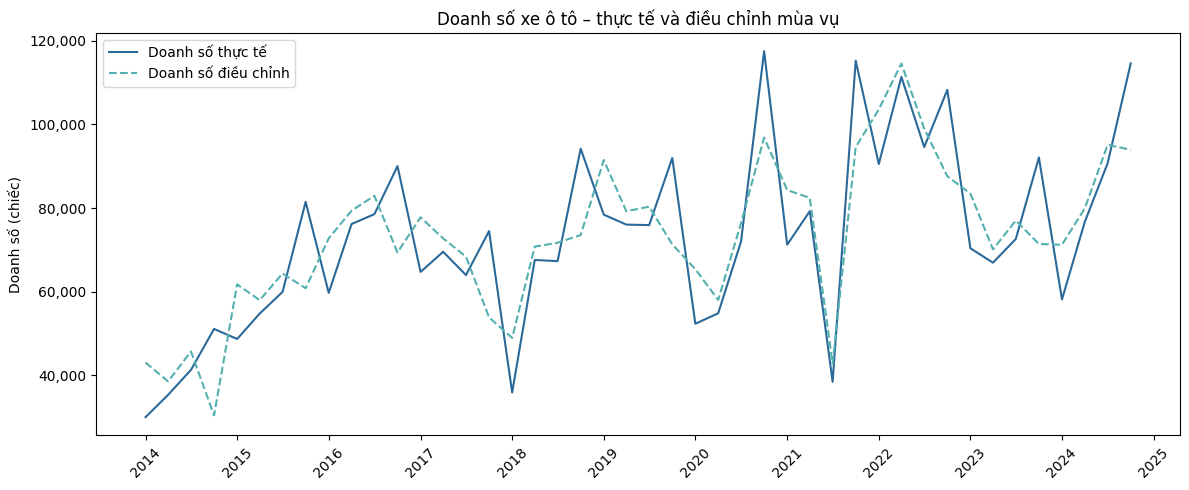

In [23]:
# Đồ thị: doanh số thực tế vs. doanh số điều chỉnh mùa vụ
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_car["qdate"], df_car["sales"],
        color=palette[2], linewidth=1.5, label="Doanh số thực tế")
ax.plot(df_car["qdate"], df_car["sales_adj"],
        color=palette[0], linewidth=1.5, linestyle="--", label="Doanh số điều chỉnh")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
ax.set_ylabel("Doanh số (chiếc)")
ax.set_title("Doanh số xe ô tô – thực tế và điều chỉnh mùa vụ")
ax.legend(loc="upper left")
plt.tight_layout()

---
# 5.10 Hồi quy tuyến tính Piecewise (Hồi quy từng phần)

Hồi quy piecewise chia dữ liệu thành các đoạn tại **điểm nút (knot)** và ước lượng hệ số riêng cho từng đoạn. Điều này cho phép mô hình nắm bắt mối quan hệ **phi tuyến** nhưng vẫn giữ tính giải thích của hồi quy tuyến tính.

**Tìm điểm nút:** `mkspline` trong Stata dùng phân vị trung vị để chọn knot tối ưu.

**Mô hình có hệ số chặn riêng cho từng đoạn:**
$$\ln Y = \alpha_1 \cdot int1 + \alpha_2 \cdot int2 + \beta_1 \cdot age1 + \beta_2 \cdot age2$$

Trong đó `int1`, `int2` là indicator từng đoạn; `age1 = (age - knot)` nếu age < knot (else 0), `age2` ngược lại.

---
## Ví dụ 1 – ln_per_expenditure ~ agehead (Điểm nút: 59 tuổi)

Stata: `mkspline age0 2 = agehead` → knot = 59 → `reg ln_per_expenditure agehead if agehead <59` / `>=59`

In [24]:
import numpy as np
import matplotlib.pyplot as plt

df_mig = df_migration.copy()
df_mig["ln_per_expenditure"] = np.log(df_mig["per_expenditure"])

# Điểm nút = 59 (theo mkspline trong Stata)
KNOT_AGE = 59

# Hồi quy từng đoạn (không điều chỉnh chặn)
dfA = df_mig[df_mig["agehead"] < KNOT_AGE].copy()
dfB = df_mig[df_mig["agehead"] >= KNOT_AGE].copy()

mA = sm.OLS(dfA["ln_per_expenditure"], sm.add_constant(dfA["agehead"])).fit()
mB = sm.OLS(dfB["ln_per_expenditure"], sm.add_constant(dfB["agehead"])).fit()

print(f"=== Dưới {KNOT_AGE} tuổi (n={len(dfA)}) ===")
print(mA.summary())
print(f"\n=== Từ {KNOT_AGE} tuổi trở lên (n={len(dfB)}) ===")
print(mB.summary())

=== Dưới 59 tuổi (n=6687) ===
                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     205.7
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           5.80e-46
Time:                        10:37:10   Log-Likelihood:                -6374.6
No. Observations:                6687   AIC:                         1.275e+04
Df Residuals:                    6685   BIC:                         1.277e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4195 

In [25]:
# Mô hình piecewise có hệ số chặn riêng (hascons)
df_pw = df_mig.copy()
df_pw["age1"] = np.maximum(0, KNOT_AGE - df_pw["agehead"]) * -1  # (agehead - 59), = 0 nếu >=59
df_pw["age1"] = (df_pw["agehead"] - KNOT_AGE).clip(upper=0) * -1
# Viết lại đúng theo Stata
df_pw["age1"] = df_pw["agehead"] - KNOT_AGE
df_pw.loc[df_pw["agehead"] >= KNOT_AGE, "age1"] = 0

df_pw["age2"] = df_pw["agehead"] - KNOT_AGE
df_pw.loc[df_pw["agehead"] < KNOT_AGE, "age2"] = 0

df_pw["int1"] = (df_pw["agehead"] < KNOT_AGE).astype(int)
df_pw["int2"] = (df_pw["agehead"] >= KNOT_AGE).astype(int)

X_pw = df_pw[["int1", "int2", "age1", "age2"]]   # hascons = không add_constant
model_pw = sm.OLS(df_pw["ln_per_expenditure"], X_pw).fit()
print("=== Piecewise với hệ số chặn riêng ===")
print(model_pw.summary())
# int1 ≈ 10.177, int2 ≈ 10.030 → hai đường không liên tục tại knot
# age1 ≈ +0.013 → dưới 59 tuổi, lớn hơn 1 tuổi thì chi tiêu tăng ~1.3%
# age2 ≈ -0.008 → trên 59 tuổi, lớn hơn 1 tuổi thì chi tiêu giảm ~0.8%

=== Piecewise với hệ số chặn riêng ===
                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     85.98
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           7.02e-55
Time:                        10:37:10   Log-Likelihood:                -8800.5
No. Observations:                9399   AIC:                         1.761e+04
Df Residuals:                    9395   BIC:                         1.764e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
int1         

In [26]:
# Kiểm định sự khác biệt chặn và độ dốc (lincom tương đương)
from scipy import stats

# Kiểm tra chặn: int2 - int1
diff_intercept = model_pw.params["int2"] - model_pw.params["int1"]
se_diff_int = np.sqrt(
    model_pw.cov_params().loc["int2", "int2"]
    + model_pw.cov_params().loc["int1", "int1"]
    - 2 * model_pw.cov_params().loc["int2", "int1"]
)
t_int = diff_intercept / se_diff_int
p_int = 2 * stats.t.sf(abs(t_int), df=model_pw.df_resid)
print(f"Kiểm định int2 - int1: coef={diff_intercept:.4f}, t={t_int:.2f}, p={p_int:.3f}")
# Tương đương lincom int2 - int1 trong Stata → coef ≈ -0.146, p < 0.001

# Kiểm tra độ dốc: age2 - age1
diff_slope = model_pw.params["age2"] - model_pw.params["age1"]
se_diff_slp = np.sqrt(
    model_pw.cov_params().loc["age2", "age2"]
    + model_pw.cov_params().loc["age1", "age1"]
    - 2 * model_pw.cov_params().loc["age2", "age1"]
)
t_slp = diff_slope / se_diff_slp
p_slp = 2 * stats.t.sf(abs(t_slp), df=model_pw.df_resid)
print(f"Kiểm định age2 - age1: coef={diff_slope:.4f}, t={t_slp:.2f}, p={p_slp:.3f}")
# Tương đương lincom age2 - age1 → coef ≈ -0.021, p < 0.001

Kiểm định int2 - int1: coef=-0.1463, t=-6.24, p=0.000
Kiểm định age2 - age1: coef=-0.0211, t=-12.75, p=0.000


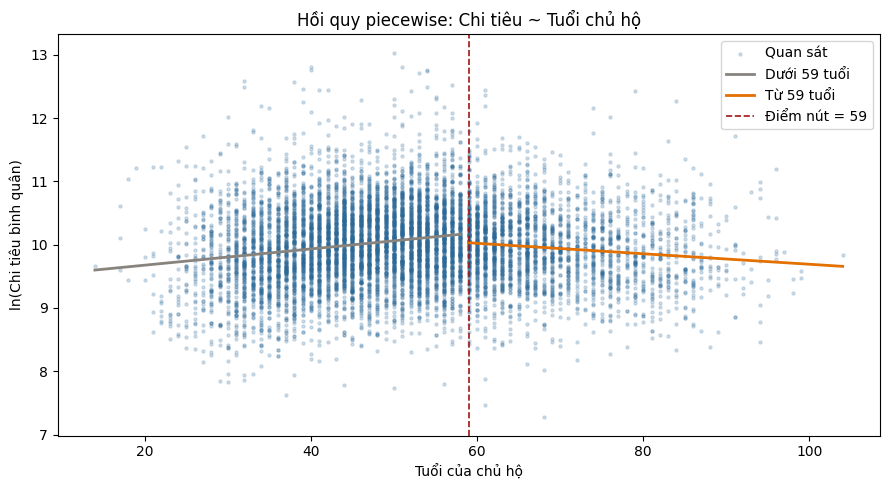

In [27]:
# Đồ thị scatter + đường piecewise
df_pw["yhat"] = model_pw.fittedvalues

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_pw["agehead"], df_pw["ln_per_expenditure"],
           color=palette[2], alpha=0.2, s=5, label="Quan sát")
ax.plot(df_pw[df_pw["agehead"] < KNOT_AGE].sort_values("agehead")["agehead"],
        df_pw[df_pw["agehead"] < KNOT_AGE].sort_values("agehead")["yhat"],
        color=palette[5], lw=2, label=f"Dưới {KNOT_AGE} tuổi")
ax.plot(df_pw[df_pw["agehead"] >= KNOT_AGE].sort_values("agehead")["agehead"],
        df_pw[df_pw["agehead"] >= KNOT_AGE].sort_values("agehead")["yhat"],
        color=palette[3], lw=2, label=f"Từ {KNOT_AGE} tuổi")
ax.axvline(KNOT_AGE, color=palette[1], linestyle="--", lw=1.2, label=f"Điểm nút = {KNOT_AGE}")
ax.set_xlabel("Tuổi của chủ hộ")
ax.set_ylabel("ln(Chi tiêu bình quân)")
ax.set_title("Hồi quy piecewise: Chi tiêu ~ Tuổi chủ hộ")
ax.legend()
plt.tight_layout()

---
## Ví dụ 2 – ln_healthcare_child ~ land (Điểm nút: 205 m²)

Stata: `mkspline land0 2 = land` → knot = 205 → tương tự ví dụ trên với biến diện tích đất

In [28]:
df_dis2 = df_disaster[df_disaster["healthcare_child"] > 0].copy()
df_dis2["ln_healthcare_child"] = np.log(df_dis2["healthcare_child"])

KNOT_LAND = 205  # mkspline cho knot = 205

# Hồi quy từng đoạn
dfL1 = df_dis2[df_dis2["land"] < KNOT_LAND].copy()
dfL2 = df_dis2[df_dis2["land"] >= KNOT_LAND].copy()

mL1 = sm.OLS(dfL1["ln_healthcare_child"], sm.add_constant(dfL1["land"] - KNOT_LAND)).fit()
mL2 = sm.OLS(dfL2["ln_healthcare_child"], sm.add_constant(dfL2["land"] - KNOT_LAND)).fit()

print(f"=== Dưới {KNOT_LAND} m² (n={len(dfL1)}) ===")
print(mL1.summary())
print(f"\n=== Từ {KNOT_LAND} m² trở lên (n={len(dfL2)}) ===")
print(mL2.summary())

=== Dưới 205 m² (n=2687) ===
                             OLS Regression Results                            
Dep. Variable:     ln_healthcare_child   R-squared:                       0.004
Model:                             OLS   Adj. R-squared:                  0.003
Method:                  Least Squares   F-statistic:                     10.29
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):            0.00135
Time:                         10:37:11   Log-Likelihood:                -3898.6
No. Observations:                 2687   AIC:                             7801.
Df Residuals:                     2685   BIC:                             7813.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

In [29]:
# Piecewise có hệ số chặn riêng
df_lnd = df_dis2.copy()
df_lnd["land1"] = df_lnd["land"] - KNOT_LAND
df_lnd.loc[df_lnd["land"] >= KNOT_LAND, "land1"] = 0

df_lnd["land2"] = df_lnd["land"] - KNOT_LAND
df_lnd.loc[df_lnd["land"] < KNOT_LAND, "land2"] = 0

df_lnd["int1"] = (df_lnd["land"] < KNOT_LAND).astype(int)
df_lnd["int2"] = (df_lnd["land"] >= KNOT_LAND).astype(int)

X_lnd = df_lnd[["int1", "int2", "land1", "land2"]]
model_lnd = sm.OLS(df_lnd["ln_healthcare_child"], X_lnd).fit()
print("=== Piecewise: ln_healthcare_child ~ land ===")
print(model_lnd.summary())
# land1 ≈ +0.0015 (p=0.001) → đất < 205 m², thêm 1 m² tăng chi phí y tế ~0.15%
# land2 ≈ +0.0040 (p=0.049) → đất >= 205 m², thêm 1 m² tăng chi phí y tế ~0.40%

=== Piecewise: ln_healthcare_child ~ land ===
                             OLS Regression Results                            
Dep. Variable:     ln_healthcare_child   R-squared:                       0.007
Model:                             OLS   Adj. R-squared:                  0.006
Method:                  Least Squares   F-statistic:                     6.398
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):           0.000257
Time:                         10:37:11   Log-Likelihood:                -4059.4
No. Observations:                 2813   AIC:                             8127.
Df Residuals:                     2809   BIC:                             8151.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [30]:
# Kiểm định độ dốc và chặn (lincom)
df_lnd["yhat"] = model_lnd.fittedvalues

diff_int_l  = model_lnd.params["int2"]  - model_lnd.params["int1"]
diff_slp_l  = model_lnd.params["land2"] - model_lnd.params["land1"]

se_int_l = np.sqrt(
    model_lnd.cov_params().loc["int2", "int2"]
    + model_lnd.cov_params().loc["int1", "int1"]
    - 2 * model_lnd.cov_params().loc["int2", "int1"]
)
se_slp_l = np.sqrt(
    model_lnd.cov_params().loc["land2", "land2"]
    + model_lnd.cov_params().loc["land1", "land1"]
    - 2 * model_lnd.cov_params().loc["land2", "land1"]
)
t_int_l = diff_int_l  / se_int_l
t_slp_l = diff_slp_l  / se_slp_l
p_int_l = 2 * stats.t.sf(abs(t_int_l), df=model_lnd.df_resid)
p_slp_l = 2 * stats.t.sf(abs(t_slp_l), df=model_lnd.df_resid)

print(f"lincom int2 - int1:   coef={diff_int_l:.4f}, t={t_int_l:.2f}, p={p_int_l:.3f}")
print(f"lincom land2 - land1: coef={diff_slp_l:.4f}, t={t_slp_l:.2f}, p={p_slp_l:.3f}")
# Chặn: coef ≈ -0.203 (p=0.206) → hai đường chặn không khác biệt có ý nghĩa
# Độ dốc: coef ≈ +0.002 (p=0.240) → hai độ dốc không khác biệt có ý nghĩa

lincom int2 - int1:   coef=-0.2033, t=-1.26, p=0.206
lincom land2 - land1: coef=0.0024, t=1.18, p=0.240


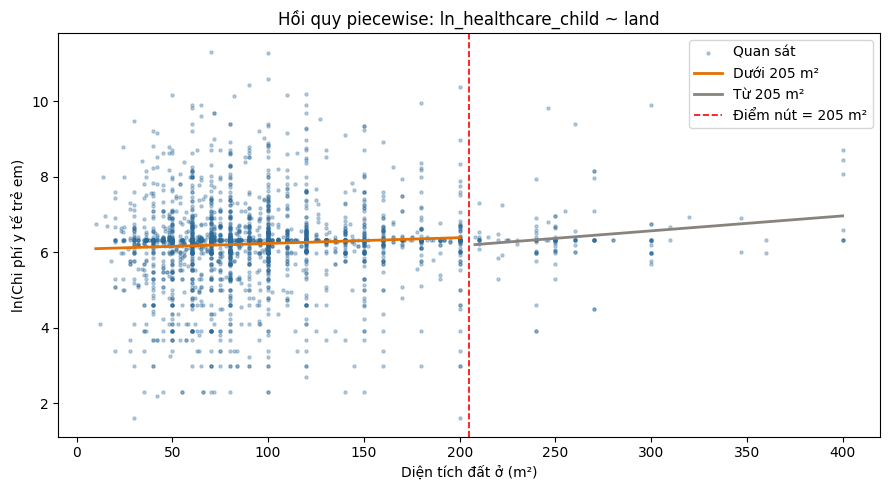

In [31]:
# Đồ thị scatter + đường piecewise
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_lnd["land"], df_lnd["ln_healthcare_child"],
           color=palette[2], alpha=0.3, s=5, label="Quan sát")
ax.plot(df_lnd[df_lnd["land"] < KNOT_LAND].sort_values("land")["land"],
        df_lnd[df_lnd["land"] < KNOT_LAND].sort_values("land")["yhat"],
        color=palette[3], lw=2, label=f"Dưới {KNOT_LAND} m²")
ax.plot(df_lnd[df_lnd["land"] >= KNOT_LAND].sort_values("land")["land"],
        df_lnd[df_lnd["land"] >= KNOT_LAND].sort_values("land")["yhat"],
        color=palette[5], lw=2, label=f"Từ {KNOT_LAND} m²")
ax.axvline(KNOT_LAND, color="red", linestyle="--", lw=1.2, label=f"Điểm nút = {KNOT_LAND} m²")
ax.set_xlabel("Diện tích đất ở (m²)")
ax.set_ylabel("ln(Chi phí y tế trẻ em)")
ax.set_title("Hồi quy piecewise: ln_healthcare_child ~ land")
ax.legend()
plt.tight_layout()

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

### <h3 align="center"> © 2026 Nhung Truong. Licensed under CC BY 4.0 </h3>